In [13]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

## Vanila-DeepONet

-, Step 1: load data \
-, Step 2: Training \
-, Step 3: Test performance & Tracking

#### Step 1: Load data

input shape - different u_0: (250, 1000)
output shape - different u_t: (250, 1000, 1000)
x shape: (1000,)
t_domain shape: (1000,)


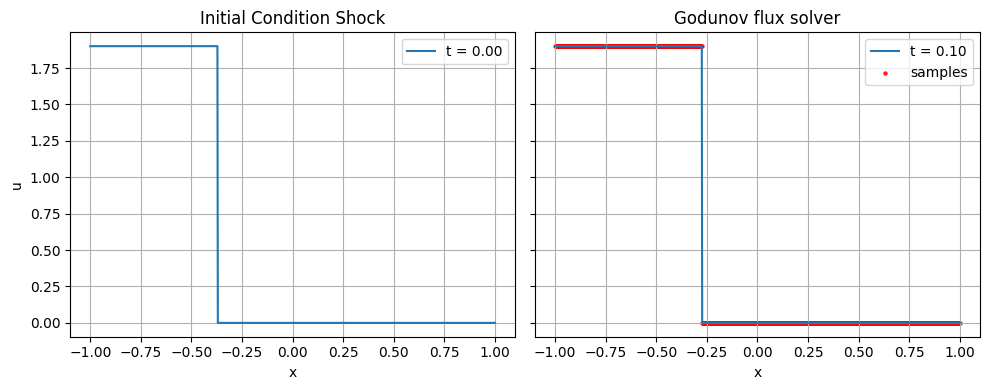

In [14]:
def plot_solution(x, u_0, u_t, t_plot,dt):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    ax1.plot(x, u_0, label="t = 0.00")
    ax1.set_xlabel("x")
    ax1.set_ylabel("u")
    ax1.set_title("Initial Condition Shock")
    ax1.legend()
    ax1.grid()

    ax2.plot(x, u_t[int(t_plot/dt)], label="t = %.2f" % t_plot)
    ax2.scatter(x, u_t[int(t_plot/dt)], color='red', s=5, label="samples", alpha=0.8)
    ax2.set_xlabel("x")
    ax2.set_title("Godunov flux solver")
    ax2.legend()
    ax2.grid()

    plt.tight_layout()
    plt.show()

N_data = 250
data = np.load(f"data/exact_solution_dataset_N_{N_data}_one_discontinuity.npz", allow_pickle=True)

input_data = data["X"]
output_data = data["Y"]
x, t_domain = data["x"], data["t"]

print("input shape - different u_0:", input_data.shape)
print("output shape - different u_t:", output_data.shape)
print("x shape:", x.shape)
print("t_domain shape:", t_domain.shape)
plot_solution(x, input_data[0, :], output_data[0, :], t_domain[200], dt=t_domain[1]-t_domain[0])

#### Step 2: Training

In [15]:
# ---------------------------
# 1) Prepare data
# ---------------------------
input = input_data.astype(np.float32)          # (N, Nx)
output = output_data.astype(np.float32)        # (N, Nt, Nx)
N, Nx, Nt = input_data.shape[0], x.shape[0], t_domain.shape[0]

# coordinate grid for trunk input: (x, t)
xx, tt = np.meshgrid(x.astype(np.float32), t_domain.astype(np.float32), indexing="xy")
coords_np = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)

# train/val split
rng = np.random.default_rng(42)
all_idx = np.arange(N)
rng.shuffle(all_idx)
n_train = int(0.9 * N) # 90% for training, 10% for validation

train_idx, val_idx = all_idx[:n_train], all_idx[n_train:]

# ---------------------------
# 2) Define DeepONet
# ---------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class DeepONet(nn.Module):
    def __init__(self, branch_in, trunk_in=2, latent_dim=128, hidden_dim=256, depth=3):
        super().__init__()
        self.branch = MLP(branch_in, hidden_dim, latent_dim, depth=depth)
        self.trunk = MLP(trunk_in, hidden_dim, latent_dim, depth=depth)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch_input, trunk_input):
        # branch_input: (B, Nx), trunk_input: (P, 2)
        b = self.branch(branch_input)      # (B, latent)
        t = self.trunk(trunk_input)        # (P, latent)
        y = b @ t.T + self.bias            # (B, P)
        return y

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepONet(branch_in=Nx, latent_dim=128, hidden_dim=350, depth=3).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)
loss_fn = nn.MSELoss()

# ---------------------------
# 3) Train
# ---------------------------
epochs = 300
batch_size = 8
points_per_step = 2000  # sampled (x,t) points per batch
train_losses, val_losses = [], []

for epoch in range(1, epochs + 1):
    model.train()
    rng.shuffle(train_idx)
    epoch_loss = 0.0
    n_batches = 0

    for start in range(0, len(train_idx), batch_size):
        # Input and Output for the current batch
        batched_idx = train_idx[start:start + batch_size]
        batched_input = torch.tensor(input[batched_idx], dtype=torch.float32, device=device)   # (B, Nx)
        batched_output = torch.tensor(output[batched_idx], dtype=torch.float32, device=device) # (B, Nt, Nx)

        # Randomly sample points in the (t,x) domain for training
        point_idx = rng.integers(0, Nt * Nx, size=points_per_step)
        t_idx, x_idx = point_idx // Nx, point_idx % Nx

        # Trunk input and target output for the sampled points
        trunk_pts = torch.tensor(coords_np[point_idx], dtype=torch.float32, device=device)  # (P, 2)
        output_target = torch.tensor(batched_output[:, t_idx, x_idx], dtype=torch.float32, device=device)  # (P, B)

        optimizer.zero_grad()
        output_pred = model(batched_input, trunk_pts)
        loss = loss_fn(output_pred, output_target)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    train_losses.append(epoch_loss / max(n_batches, 1))

    # quick validation (random sampled points)
    model.eval()
    with torch.no_grad():
        batched_val = val_idx if len(val_idx) <= 32 else rng.choice(val_idx, size=32, replace=False)
        batched_input_val = torch.tensor(input[batched_val], dtype=torch.float32, device=device)
        batched_output_val = output[batched_val]
        
        point_idx = rng.integers(0, Nt * Nx, size=points_per_step)
        t_idx, x_idx = point_idx // Nx, point_idx % Nx

        trunk_val = torch.tensor(coords_np[point_idx], dtype=torch.float32, device=device)
        y_val_target = torch.tensor(batched_output_val[:, t_idx, x_idx], dtype=torch.float32, device=device)

        y_val_pred = model(batched_input_val, trunk_val)
        val_loss = loss_fn(y_val_pred, y_val_target).item()
        val_losses.append(val_loss)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | train_loss={train_losses[-1]:.6e} | val_loss={val_losses[-1]:.6e}")

# save checkpoint
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epochs": epochs,
    "train_losses": train_losses,
    "val_losses": val_losses
}

torch.save(checkpoint, "checkpoints/vanilla_deeponet_checkpoint.pt")
print("Saved: vanilla_deeponet_checkpoint.pt")

C:\Users\Ha\AppData\Local\Temp\ipykernel_13876\3233105823.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  output_target = torch.tensor(batched_output[:, t_idx, x_idx], dtype=torch.float32, device=device)  # (P, B)


Epoch    1/300 | train_loss=2.693562e-01 | val_loss=1.713834e-01
Epoch   20/300 | train_loss=7.865276e-02 | val_loss=6.454766e-02
Epoch   40/300 | train_loss=5.839585e-02 | val_loss=4.984062e-02
Epoch   60/300 | train_loss=4.589963e-02 | val_loss=3.958463e-02
Epoch   80/300 | train_loss=4.100590e-02 | val_loss=3.451868e-02
Epoch  100/300 | train_loss=3.843918e-02 | val_loss=3.081326e-02
Epoch  120/300 | train_loss=3.986243e-02 | val_loss=3.194894e-02
Epoch  140/300 | train_loss=3.268835e-02 | val_loss=2.762789e-02
Epoch  160/300 | train_loss=3.136973e-02 | val_loss=2.927927e-02
Epoch  180/300 | train_loss=2.962546e-02 | val_loss=2.789630e-02
Epoch  200/300 | train_loss=2.787044e-02 | val_loss=2.485500e-02
Epoch  220/300 | train_loss=2.778757e-02 | val_loss=2.330820e-02
Epoch  240/300 | train_loss=2.605860e-02 | val_loss=2.391526e-02
Epoch  260/300 | train_loss=2.502659e-02 | val_loss=2.315778e-02
Epoch  280/300 | train_loss=2.773829e-02 | val_loss=2.352875e-02
Epoch  300/300 | train_lo

#### Step 3: Test performance & Tracking

In [16]:
def predict_full_field(model, x_func_np, coords_np, Nt, Nx, chunk=20000):
    preds = []
    x_func = torch.tensor(x_func_np[None, :], dtype=torch.float32, device=device)  # (1, Nx)
    with torch.no_grad():
        for i in range(0, coords_np.shape[0], chunk):
            c = torch.tensor(coords_np[i:i+chunk], dtype=torch.float32, device=device)
            p = model(x_func, c).squeeze(0).cpu().numpy()
            preds.append(p)

    return np.concatenate(preds).reshape(Nt, Nx)

def error_analysis_all_t(pred, true, xx, true_discon, window_size=5):
    abs_err = np.abs(pred - true)
    l1_loss = np.mean(abs_err)

    # Area near the discontinuity
    disc_idx = np.array([np.argmin(np.abs(xx[idx, :] - true_discon[idx])) for idx in range(xx.shape[0])])

    left_bound = np.maximum(disc_idx - window_size, 0)
    right_bound = np.minimum(xx.shape[1], disc_idx + window_size + 1)

    # l1_loss near discontinuity
    abs_err_near_dis = np.array([abs_err[i, left_bound[i]:right_bound[i]] for i in range(abs_err.shape[0])])
    l1_loss_near_discon = np.mean(abs_err_near_dis)

    return l1_loss, l1_loss_near_discon, left_bound, right_bound

def error_analysis_dataset_test(model, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, window_size=5):
    xx, tt = np.meshgrid(x_test.astype(np.float32), t_domain_test.astype(np.float32), indexing="xy")
    coords_np_test = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)

    l1_loss_all, l1_loss_near_discon_all = [], []
    for sample_id in range(input_data_test.shape[0]):
        pred_field = predict_full_field(model, input_data_test[sample_id], coords_np_test, Nt, Nx, chunk=20000)

        l1_loss, l1_loss_near_discon, _, _ = error_analysis_all_t(pred_field, output_data_test[sample_id], xx, true_discon=discon_x_data_test[sample_id], window_size=window_size)  
        l1_loss_all.append(l1_loss)
        l1_loss_near_discon_all.append(l1_loss_near_discon)

    return l1_loss_all, l1_loss_near_discon_all

def show_results(model, checkpoint, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, sample_id):
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]

    xx, tt = np.meshgrid(x_test.astype(np.float32), t_domain_test.astype(np.float32), indexing="xy")
    coords_np_test = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)
    
    pred_field = predict_full_field(model, input_data_test[sample_id], coords_np_test, Nt, Nx, chunk=20000)
    true_field = output_data_test[sample_id]

    _, _, left_bound, right_bound = error_analysis_all_t(pred_field, true_field, xx, true_discon=discon_x_data_test[sample_id], window_size=int(0.05 * Nx))  # 5% of total points on each side of the discontinuity

    t_plot = 0.07
    t_idx = int(t_plot / (t_domain_test[1] - t_domain_test[0]))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    axes[0].plot(x_test, input_data_test[sample_id], color="blue", label="Initial condition")
    axes[0].set_title("Input function u_0")
    axes[0].set_xlabel("x")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(x_test, pred_field[t_idx], color="red", label="Pred")
    axes[1].plot(x_test, true_field[t_idx], color="blue", linestyle="--", label="True")
    axes[1].axvline(x_test[left_bound[t_idx]], color="green", alpha=0.5, label="Discontinuity region")
    axes[1].axvline(x_test[right_bound[t_idx]], color="green", alpha=0.5)
    axes[1].set_title(f"t={t_domain_test[t_idx]:.3f}")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(train_losses, label="Train")
    axes[2].plot(val_losses, label="Val")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("Epoch")
    axes[2].set_title("Training Curve")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

In [17]:
N_data = 20
data = np.load(f"data/exact_solution_dataset_N_{N_data}_one_discontinuity_test.npz", allow_pickle=True)
discon_data = np.load(f"data/exact_solution_discontinuity_dataset_N_{N_data}_one_discontinuity_test.npz")

input_data_test, output_data_test = data["X"], data["Y"]
discon_x_data_test = discon_data["Y"].astype(np.float32)
x_test = data["x"]
t_domain_test = data["t"]

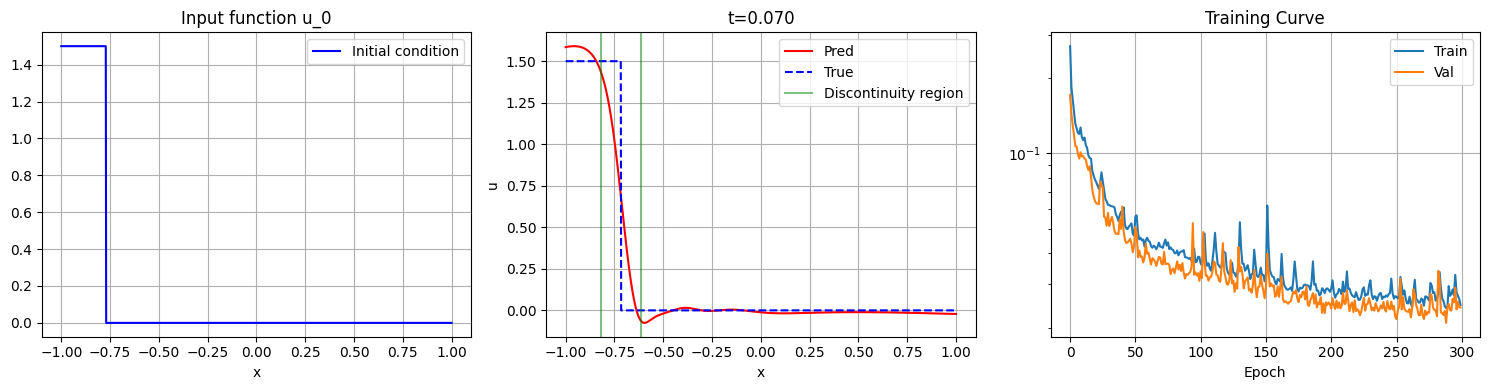

Total parameters: 932,657, trainable parameters: 932,657
L1 Loss (all points): 0.089, std: 0.026
L1 Loss (near discontinuity): 0.407, std: 0.100


In [18]:
# Load the trained Lifted-DeepONet model
checkpoint = torch.load("checkpoints/vanilla_deeponet_checkpoint.pt", map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

l1_loss_all, l1_loss_near_discon_all = error_analysis_dataset_test(model, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, window_size=int(0.05 * Nx))
show_results(model, checkpoint, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, sample_id=1)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}, trainable parameters: {trainable_params:,}")
print(f"L1 Loss (all points): {np.mean(l1_loss_all):.3f}, std: {np.std(l1_loss_all):.3f}")
print(f"L1 Loss (near discontinuity): {np.mean(l1_loss_near_discon_all):.3f}, std: {np.std(l1_loss_near_discon_all):.3f}")